In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
g = 9.81               # gravity (m/s²)
rho = 1.06             # estimated air density (kg/m³)
Cd = 0.68              # drag coef
m = 0.595              # rocket mass (kg)
A_base = 0.00452369    # min drag area (m²) — rocket body
A_max = 0.00524229     # max drag area (m²) — with brakes fully deployed
target_apogee = 228.6  # meters

# Initial conditions
t = 0                  # reset time at burnout
h0 = 76.02             # initial height (m)
v0 = 69.95             # initial upward velocity (m/s)

In [ ]:
dt = 0.01                              # timestep (s)
deploy_alts = np.arange(100, 224, 5)
results = []
print(deploy_alts)

[100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175 180 185
 190 195 200 205 210 215 220]


In [ ]:
def simulate(deploy_altitude):
    h = h0
    v = v0
    t = 0
    while v > 0:
        A = A_base if h < deploy_altitude else A_max
        F_d = 0.5 * rho * Cd * A * v**2
        a = -g - F_d / m
        v += a * dt
        h += v * dt
        t += dt
        # Prevent unrealistic heights
        if h < 0:
            break

    return h  # final apogee

In [ ]:
for alt in deploy_alts:
    apogee = simulate(alt)
    results.append((alt, apogee))
print(results)

[(np.int64(100), 226.8996987928826), (np.int64(105), 227.26820473909356), (np.int64(110), 227.66009643777087), (np.int64(115), 227.99078520640427), (np.int64(120), 228.34201454093338), (np.int64(125), 228.67280872643764), (np.int64(130), 229.01878201755224), (np.int64(135), 229.30957547695468), (np.int64(140), 229.6410406359151), (np.int64(145), 229.92162134473637), (np.int64(150), 230.2063362185377), (np.int64(155), 230.4694321409987), (np.int64(160), 230.73118092454146), (np.int64(165), 230.96888565377026), (np.int64(170), 231.20249261845518), (np.int64(175), 231.4105176871399), (np.int64(180), 231.61038711576916), (np.int64(185), 231.79672771857219), (np.int64(190), 231.96870416101953), (np.int64(195), 232.12217518206117), (np.int64(200), 232.2573604202303), (np.int64(205), 232.37150789399408), (np.int64(210), 232.47447463917217), (np.int64(215), 232.55784410407915), (np.int64(220), 232.62016211712032)]


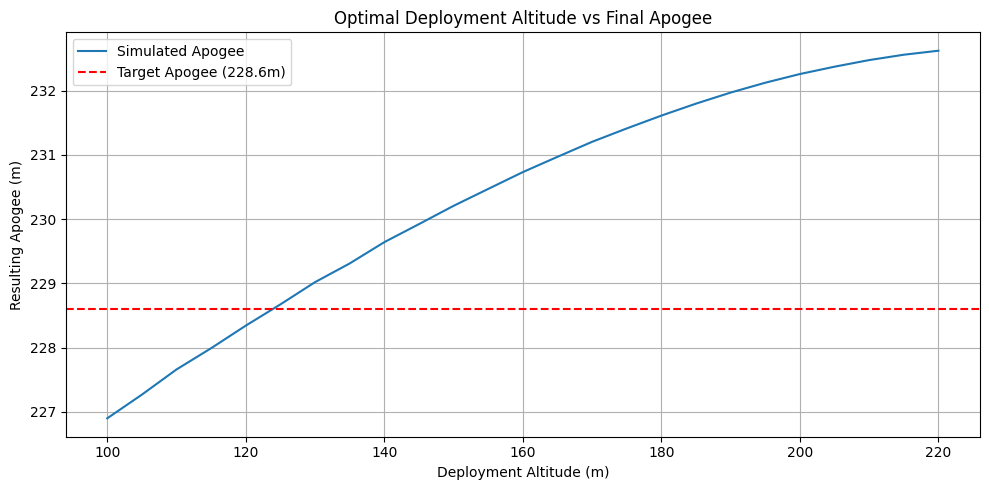

In [ ]:
alts, apogees = zip(*results)
plt.figure(figsize=(10,5))
plt.plot(alts, apogees, label='Simulated Apogee')
plt.axhline(y=target_apogee, color='r', linestyle='--', label='Target Apogee (228.6m)')
plt.xlabel('Deployment Altitude (m)')
plt.ylabel('Resulting Apogee (m)')
plt.title('Optimal Deployment Altitude vs Final Apogee')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()